---
<center>

# Cortes v2 (automatizado)

---

1. Carga de datos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops

t1 = np.load("mapa_T1.npy")
t2 = np.load("mapa_T2.npy")

t1 = np.nan_to_num(t1, nan=0.0)
t2 = np.nan_to_num(t2, nan=0.0)

print("Shape T1:", t1.shape)
print("Shape T2:", t2.shape)

Shape T1: (160, 192, 64)
Shape T2: (160, 192, 64)


2. Suavizado Gaussiano

In [2]:
sigma = 1.0

t1_smooth = ndi.gaussian_filter(t1, sigma=sigma)
t2_smooth = ndi.gaussian_filter(t2, sigma=sigma)

3. Mascara binaria y deteccion de semilla

In [3]:
z_shape, y_shape, x_shape = t1_smooth.shape

# ventana espacial
z_start, z_end = int(z_shape * 0.25), int(z_shape * 0.75)
y_start, y_end = int(y_shape * 0.25), int(y_shape * 0.75)
x_start, x_end = int(x_shape * 0.25), int(x_shape * 0.75)

spatial_mask = np.zeros_like(t1_smooth, dtype=bool)
spatial_mask[z_start:z_end, y_start:y_end, x_start:x_end] = True
t1_center = t1_smooth * spatial_mask

#threshold
t1_nonzero = t1_center[t1_center > 0.01]
thresh = threshold_otsu(t1_nonzero)
mask_estricta = t1_center > (thresh * 1.5) 

#deteccion semilla central
z_indices = np.where(np.any(mask_estricta, axis=(1, 2)))[0]
z_mid = z_indices[len(z_indices)//2]

#transf de dist 
dist_map = ndi.distance_transform_edt(mask_estricta[z_mid])
coord_y, coord_x = np.unravel_index(np.argmax(dist_map), dist_map.shape)

print(f"Semilla en: Z={z_mid}, Y={coord_y}, X={coord_x}")

Semilla en: Z=80, Y=109, X=38


4. Visualización

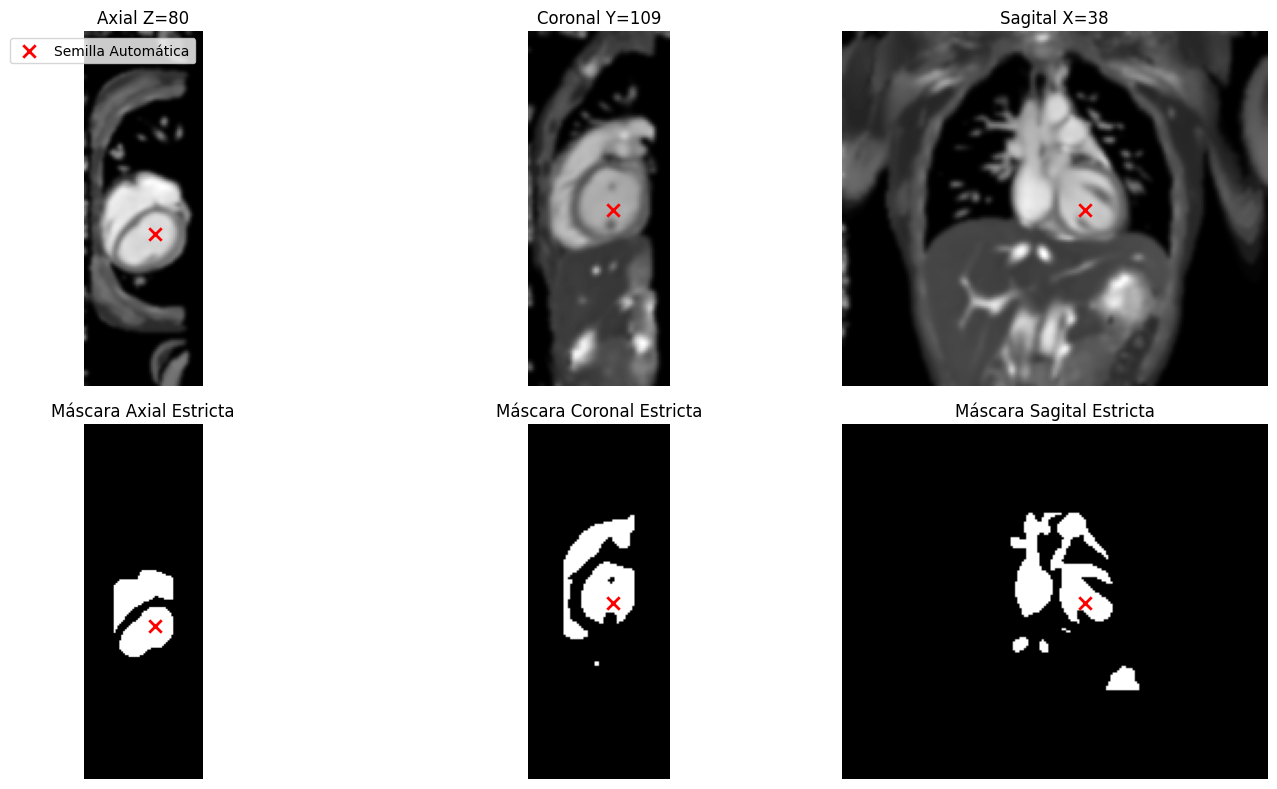

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

#fila de arriba
axes[0,0].imshow(t1_smooth[z_mid,:,:], cmap="gray")
axes[0,0].scatter(coord_x, coord_y, c="red", s=80, marker="x", linewidths=2, label="Semilla Automática")
axes[0,0].set_title(f"Axial Z={z_mid}")
axes[0,0].legend()

axes[0,1].imshow(t1_smooth[:,coord_y,:], cmap="gray")
axes[0,1].scatter(coord_x, z_mid, c="red", s=80, marker="x", linewidths=2)
axes[0,1].set_title(f"Coronal Y={coord_y}")

axes[0,2].imshow(t1_smooth[:,:,coord_x], cmap="gray")
axes[0,2].scatter(coord_y, z_mid, c="red", s=80, marker="x", linewidths=2)
axes[0,2].set_title(f"Sagital X={coord_x}")

#fila de abajo
axes[1,0].imshow(mask_estricta[z_mid,:,:], cmap="gray")
#semilla sobre la mascara
axes[1,0].scatter(coord_x, coord_y, c="red", s=80, marker="x", linewidths=2)
axes[1,0].set_title("Máscara Axial Estricta")

axes[1,1].imshow(mask_estricta[:,coord_y,:], cmap="gray")
axes[1,1].scatter(coord_x, z_mid, c="red", s=80, marker="x", linewidths=2)
axes[1,1].set_title("Máscara Coronal Estricta")

axes[1,2].imshow(mask_estricta[:,:,coord_x], cmap="gray")
axes[1,2].scatter(coord_y, z_mid, c="red", s=80, marker="x", linewidths=2)
axes[1,2].set_title("Máscara Sagital Estricta")

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()

5. Automatización de Landmarks

In [5]:
cy_semilla = coord_y
cx_semilla = coord_x
z_mid = z_indices[len(z_indices)//2]

cz_list, cy_list, cx_list = [z_mid], [cy_semilla], [cx_semilla]

radio_busqueda = 3

def buscar_centro_robusto(corte_z, y_prev, x_prev):
    slice_mask = mask_estricta[corte_z]
    
    y_min = max(0, int(y_prev) - radio_busqueda)
    y_max = min(slice_mask.shape[0], int(y_prev) + radio_busqueda)
    x_min = max(0, int(x_prev) - radio_busqueda)
    x_max = min(slice_mask.shape[1], int(x_prev) + radio_busqueda)
    
    ventana = slice_mask[y_min:y_max, x_min:x_max]
    
    #muy vacia 
    if np.sum(ventana) < 10: 
        return None, None
        
    dist_map = ndi.distance_transform_edt(ventana)
    
    #hacia el centro de la ventana
    centro_y_local = int(y_prev) - y_min
    centro_x_local = int(x_prev) - x_min
    
    Y, X = np.ogrid[:ventana.shape[0], :ventana.shape[1]]
    distancia = np.sqrt((Y - centro_y_local)**2 + (X - centro_x_local)**2)
    
    pesos = np.exp(-0.5 * distancia)
    dist_pesada = dist_map * pesos
    
    local_y, local_x = np.unravel_index(np.argmax(dist_pesada), dist_pesada.shape)
    
    #stop si pega un salto
    if np.sqrt((local_y - centro_y_local)**2 + (local_x - centro_x_local)**2) > 3.0:
        return None, None
        
    return y_min + local_y, x_min + local_x

#hacia el apex
cy_temp, cx_temp = cy_semilla, cx_semilla
for z in range(z_mid + 1, mask_estricta.shape[0]):
    cy_temp, cx_temp = buscar_centro_robusto(z, cy_temp, cx_temp)
    if cy_temp is not None:
        cz_list.append(z)
        cy_list.append(cy_temp)
        cx_list.append(cx_temp)
    else:
        break

#hacia la base
cy_temp, cx_temp = cy_semilla, cx_semilla
for z in range(z_mid - 1, -1, -1):
    cy_temp, cx_temp = buscar_centro_robusto(z, cy_temp, cx_temp)
    if cy_temp is not None:
        cz_list.append(z)
        cy_list.append(cy_temp)
        cx_list.append(cx_temp)
    else:
        break

#ordenamos los puntos
cz_arr = np.array(cz_list)
cy_arr = np.array(cy_list)
cx_arr = np.array(cx_list)

sort_idx = np.argsort(cz_arr)
z_valid = cz_arr[sort_idx]
y_valid = cy_arr[sort_idx]
x_valid = cx_arr[sort_idx]

poly_y = np.poly1d(np.polyfit(z_valid, y_valid, 2))
poly_x = np.poly1d(np.polyfit(z_valid, x_valid, 2))

spline_z = np.linspace(z_valid[0], z_valid[-1], 100)
spline_y = poly_y(spline_z)
spline_x = poly_x(spline_z)

p_base = np.array([spline_z[0], spline_y[0], spline_x[0]])
p_apex = np.array([spline_z[-1], spline_y[-1], spline_x[-1]])

print("Landmarks:")
print(f"Base : [{p_base[0]:.1f}, {p_base[1]:.1f}, {p_base[2]:.1f}]")
print(f"Apex : [{p_apex[0]:.1f}, {p_apex[1]:.1f}, {p_apex[2]:.1f}]")

Landmarks:
Base : [62.0, 108.2, 39.1]
Apex : [88.0, 112.8, 38.2]


6. Visualizacion

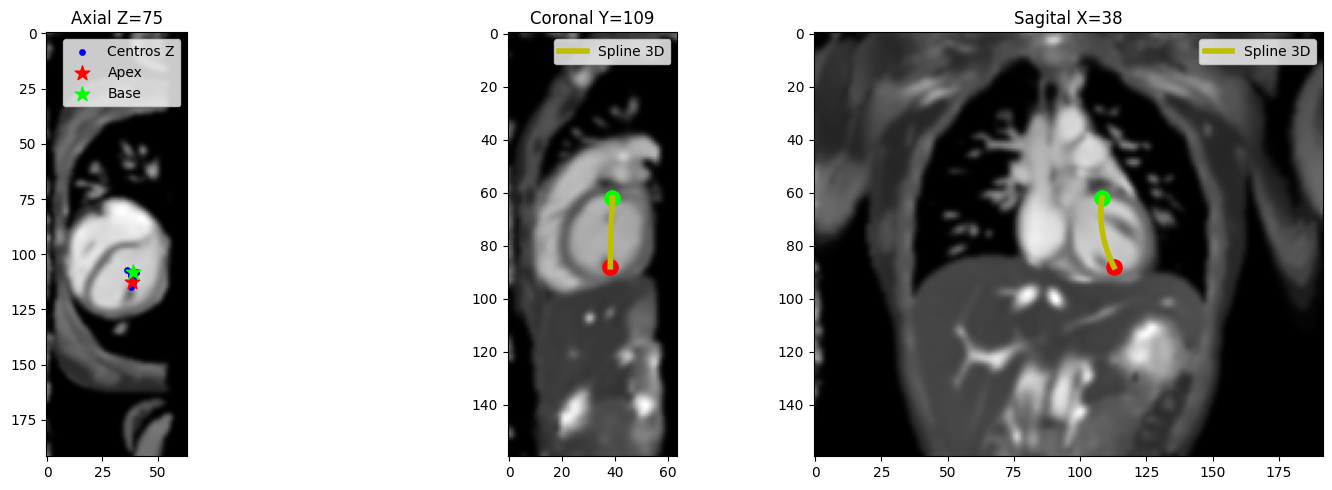

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

y_central = int(np.mean(y_valid))
x_central = int(np.mean(x_valid))
z_centro = int(np.mean(z_valid))

#AXIAL
axes[0].imshow(t1_smooth[z_centro], cmap="gray")
axes[0].scatter(x_valid, y_valid, c="blue", s=15, label="Centros Z")
axes[0].scatter(p_apex[2], p_apex[1], c="red", s=120, marker="*", label="Apex")
axes[0].scatter(p_base[2], p_base[1], c="lime", s=120, marker="*", label="Base")
axes[0].set_title(f"Axial Z={z_centro}")
axes[0].legend()

#CORONAL
axes[1].imshow(t1_smooth[:, y_central, :], cmap="gray")
axes[1].plot(spline_x, spline_z, "y-", linewidth=4, label="Spline 3D")
axes[1].scatter(p_apex[2], p_apex[0], c="red", s=120)
axes[1].scatter(p_base[2], p_base[0], c="lime", s=120)
axes[1].set_title(f"Coronal Y={y_central}")
axes[1].legend()

#SAGITAL
axes[2].imshow(t1_smooth[:, :, x_central], cmap="gray")
axes[2].plot(spline_y, spline_z, "y-", linewidth=4, label="Spline 3D")
axes[2].scatter(p_apex[1], p_apex[0], c="red", s=120)
axes[2].scatter(p_base[1], p_base[0], c="lime", s=120)
axes[2].set_title(f"Sagital X={x_central}")
axes[2].legend()

plt.tight_layout()
plt.show()

7. Reformateo SAX 

In [7]:
from scipy.ndimage import map_coordinates

def reformatear_sax_curva(volumen, z_start, z_end, poly_y, poly_x, tamaño=100, nslices=25):
    sax = np.zeros((nslices, tamaño, tamaño))
    half = tamaño / 2.0
    rango = np.linspace(-half, half, tamaño)
    UU, VV = np.meshgrid(rango, rango)
    
    deriv_y = poly_y.deriv()
    deriv_x = poly_x.deriv()
    
    z_max_val = max(z_start, z_end)
    z_min_val = min(z_start, z_end)
    
    z_offsets = np.linspace(z_max_val, z_min_val, nslices)
    
    for i, z in enumerate(z_offsets):
        centro = np.array([z, poly_y(z), poly_x(z)])
        
        dy = deriv_y(z)
        dx = deriv_x(z)
        
        tangente = np.array([1.0, dy, dx])
        eje = tangente / np.linalg.norm(tangente)
        
        ref = np.array([0.0, 1.0, 0.0])
        if abs(np.dot(eje, ref)) > 0.9:
            ref = np.array([1.0, 0.0, 0.0])
            
        u = np.cross(eje, ref)
        u = u / np.linalg.norm(u)
        
        v = np.cross(eje, u)
        v = v / np.linalg.norm(v)
        
        puntos = (
            centro[None, None, :]
            + UU[:, :, None] * u[None, None, :]
            + VV[:, :, None] * v[None, None, :]
        )
        
        coords = [
            puntos[:, :, 0].ravel(),
            puntos[:, :, 1].ravel(),
            puntos[:, :, 2].ravel()
        ]
        
        valores = map_coordinates(
            volumen,
            coords,
            order=1,
            mode='constant',
            cval=0
        )
        
        sax[i] = valores.reshape(tamaño, tamaño)
        
    return sax

z_base = p_base[0]
z_apex = p_apex[0]

t1_sax = reformatear_sax_curva(t1, z_base, z_apex, poly_y, poly_x, tamaño=60, nslices=20)
t2_sax = reformatear_sax_curva(t2, z_base, z_apex, poly_y, poly_x, tamaño=60, nslices=20)

print(f"Hechos {t1_sax.shape[0]} cortes SAX en T1 y T2.")

Hechos 20 cortes SAX en T1 y T2.


8. Visualizacion del SAX

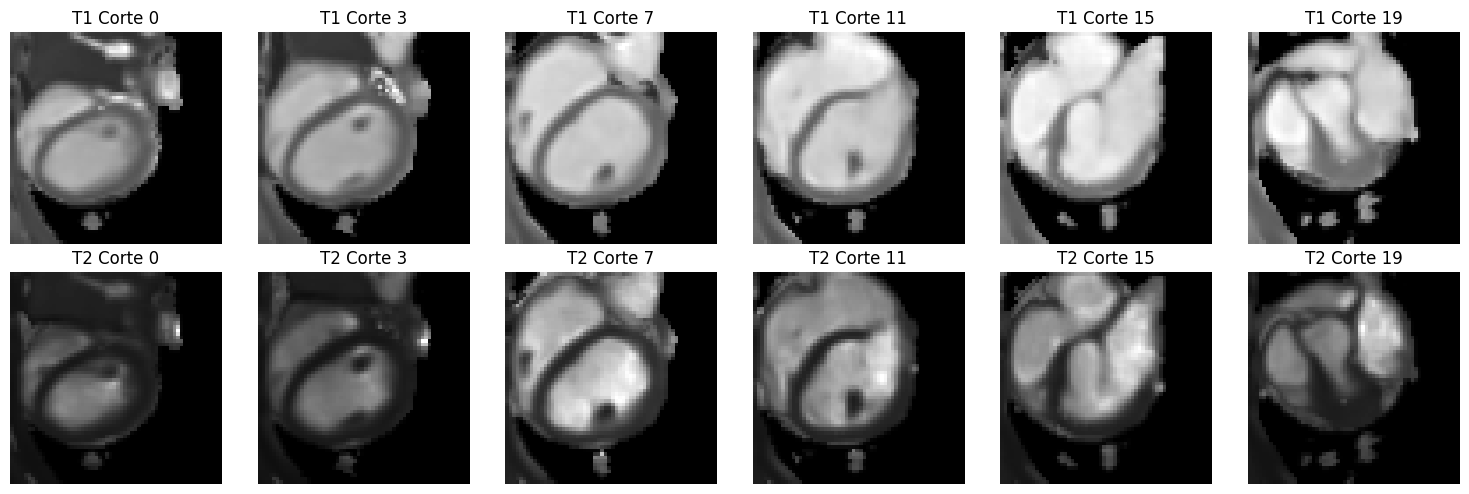

In [8]:
nslices_reales = t1_sax.shape[0]

indices = np.linspace(0, nslices_reales - 1, 6, dtype=int)

fig, axes = plt.subplots(2, 6, figsize=(15, 5))

for j, idx in enumerate(indices):
    axes[0, j].imshow(t1_sax[idx], cmap="gray", origin="lower")
    axes[0, j].axis("off")
    axes[0, j].set_title(f"T1 Corte {idx}")

    axes[1, j].imshow(t2_sax[idx], cmap="gray", origin="lower")
    axes[1, j].axis("off")
    axes[1, j].set_title(f"T2 Corte {idx}")

plt.tight_layout()
plt.savefig("resultado_SAX_final.png", dpi=300)
plt.show()

9. Guardar y exportar

In [9]:
import json

np.save("mapa_T1_SAX_v2.npy", t1_sax)
np.save("mapa_T2_SAX_v2.npy", t2_sax)
metadata = {
    "metodologia": "Pipeline automatico de reformateo SAX con tracking local (Spline 3D)",
    "apex": p_apex.tolist(),
    "base": p_base.tolist(),
    "coeficientes_spline_y": poly_y.coef.tolist(), 
    "coeficientes_spline_x": poly_x.coef.tolist(),
    "nslices": int(t1_sax.shape[0]),
    "slice_size": int(t1_sax.shape[1])
}

with open("metadata_SAX.json", "w") as f:
    json.dump(metadata, f, indent=4)
